<a href="https://colab.research.google.com/github/IsaacGSolis/Mineria-de-Datos-IEGS/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pandas as pd

In [15]:
data={
    "Horas_estudio":[1,2,1.5,8,9,8.5,3,3.5,4],
    "Calificaciones":[2,3,2.5,9,10,9.5,5,5.5,6]
}
df=pd.DataFrame(data)
df

,Horas_estudio,Calificaciones
0,1.0,2.0
1,2.0,3.0
2,1.5,2.5
3,8.0,9.0
4,9.0,10.0
5,8.5,9.5
6,3.0,5.0
7,3.5,5.5
8,4.0,6.0


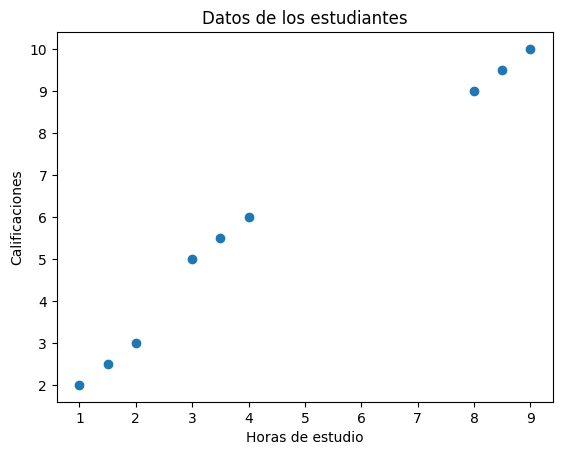

In [16]:
#Visualizacion
plt.scatter(df["Horas_estudio"],df["Calificaciones"])
plt.xlabel("Horas de estudio")
plt.ylabel("Calificaciones")
plt.title("Datos de los estudiantes")
plt.show()

In [17]:
# Calcular WCSS para diferentes números de clusters
wcss = []
max_clusters = min(len(df), 10) # Avoid more clusters than data points, limit to 10 for demonstration

for i in range(1, max_clusters + 1):
    kmeans_elbow = KMeans(n_clusters=i, random_state=42, n_init=10) # n_init for robustness
    kmeans_elbow.fit(df.drop(columns=['Cluster'], errors='ignore')) # Use original data without 'Cluster' column
    wcss.append(kmeans_elbow.inertia_)

# Mostrar los valores de WCSS
print("WCSS values for k=1 to {}:\n{}".format(max_clusters, wcss))

WCSS values for k=1 to 9:
[155.00000000000003, 22.5, 3.0, 2.25, 1.5, 0.75, 0.5, 0.25, 0.0]


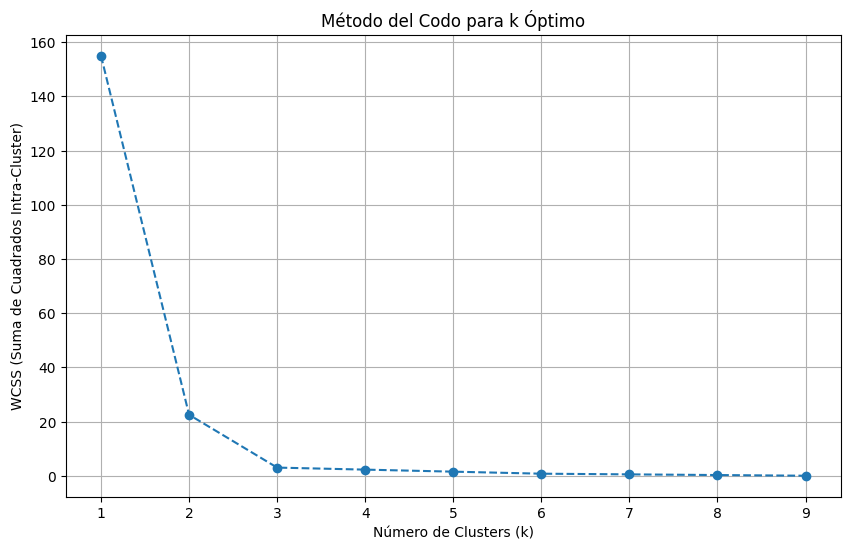

In [18]:
# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para k Óptimo')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('WCSS (Suma de Cuadrados Intra-Cluster)')
plt.grid(True)
plt.xticks(range(1, max_clusters + 1))
plt.show()

In [19]:
#Aplicar k-Means
kmeans=KMeans(n_clusters=3,random_state=42)
kmeans.fit(df)

KMeans(n_clusters=3, random_state=42)

In [20]:
#Mostrar los centroides
centroides=kmeans.cluster_centers_
centroides

array([[8.5, 9.5],
       [3.5, 5.5],
       [1.5, 2.5]])

In [21]:
df['Cluster']=kmeans.labels_
df

,Horas_estudio,Calificaciones,Cluster
0,1.0,2.0,2
1,2.0,3.0,2
2,1.5,2.5,2
3,8.0,9.0,0
4,9.0,10.0,0
5,8.5,9.5,0
6,3.0,5.0,1
7,3.5,5.5,1
8,4.0,6.0,1


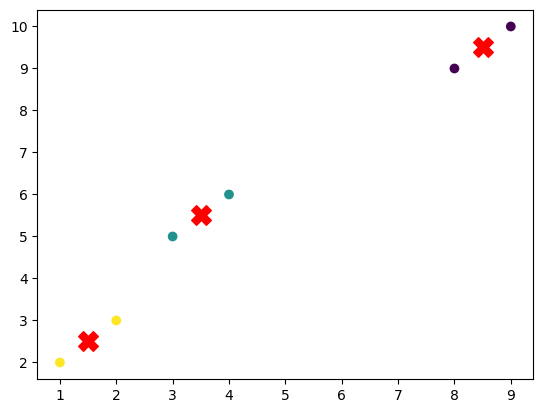

In [22]:
#Visualizamos los centroides
plt.scatter(df["Horas_estudio"],df["Calificaciones"],c=df["Cluster"])
plt.scatter(centroides[:,0],centroides[:,1],marker="X",s=200,c="red")
plt.show()